# 🇩🇿 Algérie Télécom: Intelligent Complaint Analysis and Management System
**Project:** Data Mining & AI for Customer complaint Analysis 
**Goal:** Analyse customer complaints , Automate their classification and identify hidden service patterns.

### **Notebook Structure:**
1. **Data Loading & Cleaning:** Text normalization and preparation.
2. **Exploratory Data Analysis (EDA):** Visualizing trends, urgencies, and text patterns.
3. **Clustering (Unsupervised Learning):** Grouping customers to find hidden operational issues.
4. **Feature Engineering:** Creating "Smart Labels" based on domain knowledge and statistics 
5. **Classification (Supervised Learning):** Training the AI to predict solutions.
6. **Deployment:** Running the Flask API.

## Standard setup. We also download NLTK data for text processing

In [2]:

import sys
!{sys.executable} -m pip install flask flask-cors pandas numpy scikit-learn joblib seaborn matplotlib nltk

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import random
import re
from collections import Counter
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import Birch
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Download French stopwords
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

print(" Environment Ready.")

  Using cached flask-3.1.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
Using cached flask-3.1.2-py3-none-any.whl (103 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.5 MB ? eta -:-

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\wassi\AppData\Roaming\nltk_data...


 Environment Ready.


[nltk_data]   Unzipping corpora\stopwords.zip.


## 1. Data Loading & Cleaning
We load the dataset and perform basic preprocessing:
* **Normalization:** Converting all text to lowercase.
* **Capitalization:** Formatting categorical columns (e.g., "alger" -> "Alger").
* **Stopwords:** Defining common words (e.g., "le", "la", "bonjour") to ignore during analysis.

In [3]:

try:
    df = pd.read_csv('algerietelecom.csv')
    print(f" Data Loaded: {df.shape[0]} rows.")
except FileNotFoundError:
    print(" Error: 'algerietelecom.csv' not found. Please upload it to the folder.")
df['texte_reclamation'] = df['texte_reclamation'].astype(str).str.lower()
for col in ['urgence', 'sentiment', 'categorie', 'wilaya', 'canal']:
    df[col] = df[col].astype(str).str.capitalize()

french_stop_words = stopwords.words('french')
noise_words = ['bonjour', 'merci', 'cordialement', 'monsieur', 'madame', 'j\'ai', 'suis', 'cette', 'depuis']
french_stop_words.extend(noise_words)

print(" Data Cleaned & Normalized.")

 Data Loaded: 100000 rows.
 Data Cleaned & Normalized.


## 2. Exploratory Data Analysis (EDA)
We analyze the data to understand the current state of customer service.
* **Volume Analysis:** Which categories are most frequent?
* **Geographic Analysis:** Which Wilayas complain the most?
* **Text Mining:** What are the most common words used by customers?
* **Heatmap:** How does urgency correlate with the communication channel?

C:\Users\wassi\AppData\Local\Temp\ipykernel_6312\2473284064.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='categorie', data=df, order=df['categorie'].value_counts().index, palette='viridis')


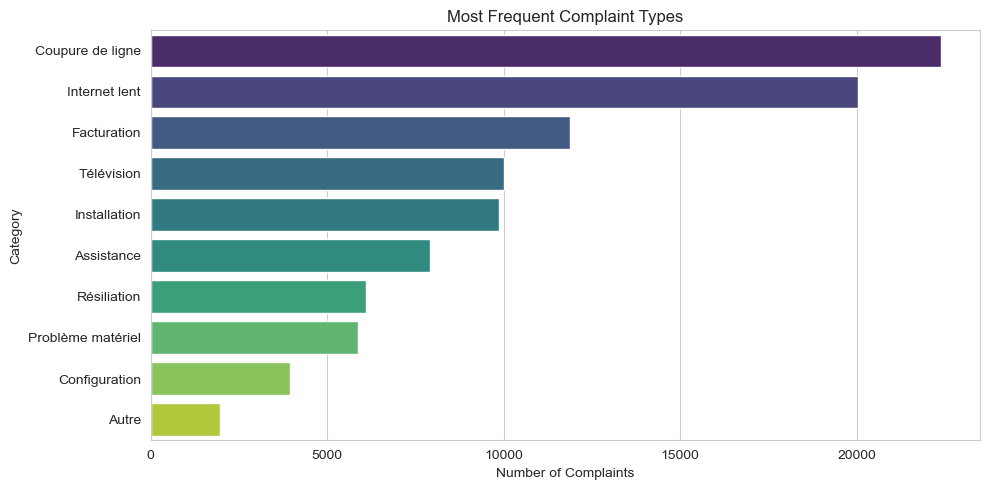

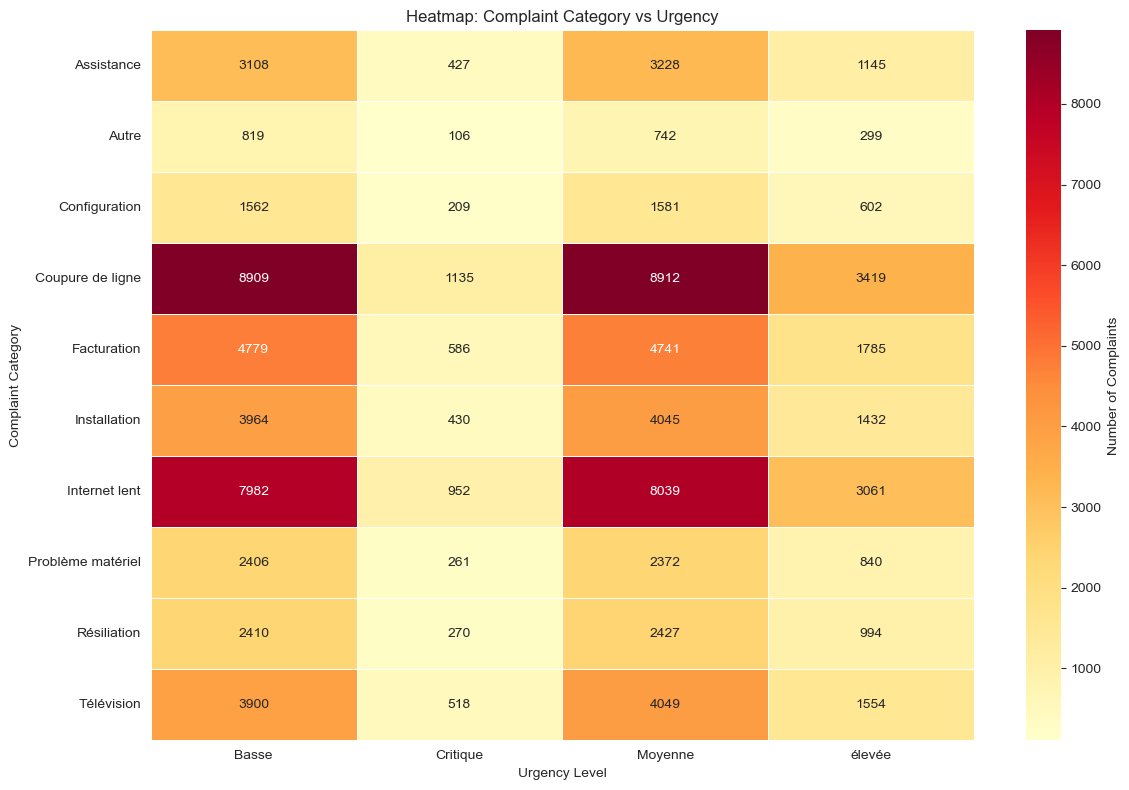

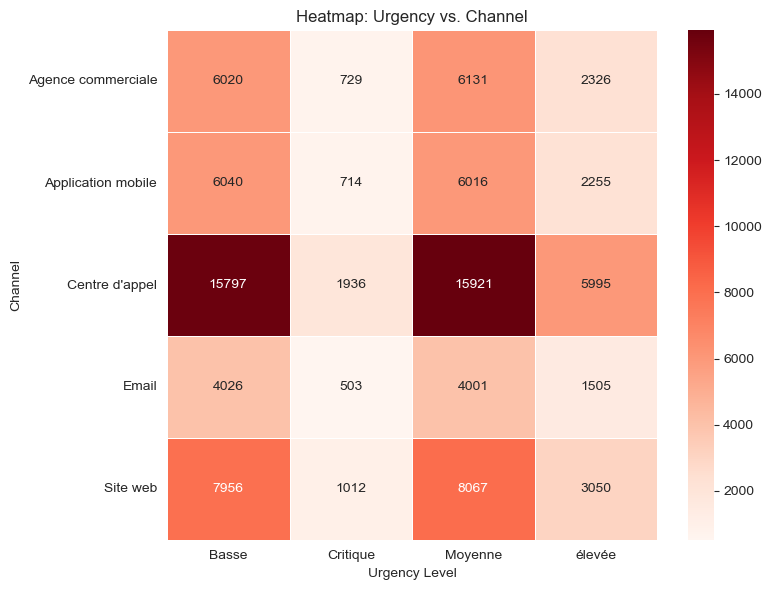

C:\Users\wassi\AppData\Local\Temp\ipykernel_6312\2473284064.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='magma')


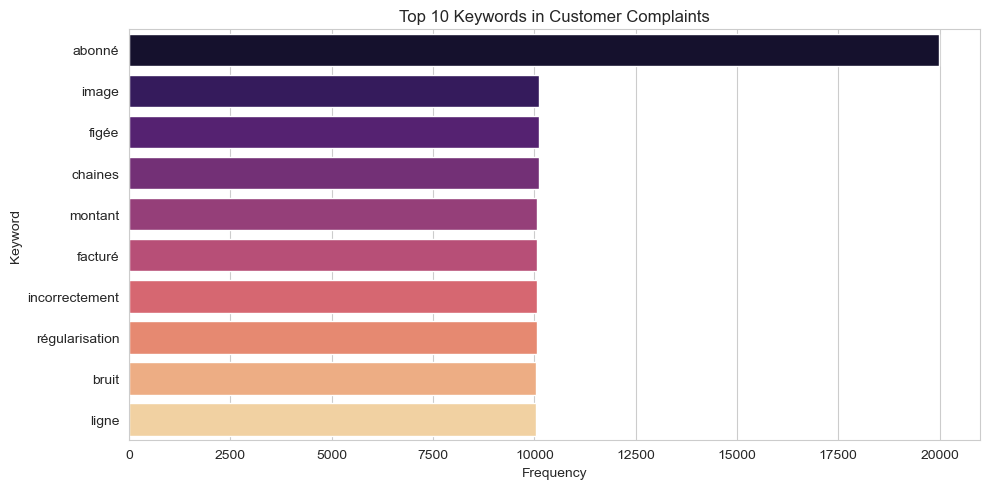

In [9]:
sns.set_style("whitegrid")

# 1. Top Categories (Bar Chart)
plt.figure(figsize=(10, 5))
sns.countplot(y='categorie', data=df, order=df['categorie'].value_counts().index, palette='viridis')
plt.title('Most Frequent Complaint Types')
plt.xlabel('Number of Complaints')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# 2. Heatmap: Complaint Category vs Urgency
heatmap_data = (
    df.groupby(["categorie", "urgence"])
      .size()
      .unstack(fill_value=0)
)

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Number of Complaints'})
plt.xlabel("Urgency Level")
plt.ylabel("Complaint Category")
plt.title("Heatmap: Complaint Category vs Urgency")
plt.tight_layout()
plt.show()

# 3. Urgency by Channel (Heatmap)
plt.figure(figsize=(8, 6))
ct = pd.crosstab(df['canal'], df['urgence'])
sns.heatmap(ct, annot=True, fmt='d', cmap='Reds', linewidths=0.5)
plt.title('Heatmap: Urgency vs. Channel')
plt.xlabel('Urgency Level')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()

# 4. Text Mining - Top Keywords
def get_top_n_words(corpus, n=10):
    vec = CountVectorizer(stop_words=french_stop_words).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

top_words = get_top_n_words(df['texte_reclamation'], 10)
words_df = pd.DataFrame(top_words, columns=['Word', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(x='Count', y='Word', data=words_df, palette='magma')
plt.title('Top 10 Keywords in Customer Complaints')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

## 3. Unsupervised Learning (Clustering)
We use a comparaison of differnet clustering algorithms then choosing the best of them **BIRCH Algorithm** to segment customers into groups.
* **Goal:** Discover hidden patterns without predefined labels.
* **Method:** We vectorize the text (TF-IDF), reduce dimensionality (SVD), and then cluster.
* **Result:** We expect to find groups like "Angry Phone Callers" or "Web Users with Modem Issues."

Data Loaded Successfully.
Transforming data...
Applying SVD to densify clusters...
Running multiple clustering algorithms for comparison...
[BIRCH] Running BIRCH clustering with n_clusters=6...
[BIRCH] Completed. All points assigned to 6 clusters.


e:\Anaconda\envs\DM_ENV\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 3072 or by setting the environment variable OMP_NUM_THREADS=8
  warnings.warn(



CLUSTERING METRICS COMPARISON
Algorithm       Silhouette ↑    Calinski-Harabasz ↑  Davies-Bouldin ↓
----------------------------------------------------------------------
KMeans          0.6744          182942.9             0.5177
GMM             0.7451          258622.7             0.4306
BIRCH           0.8139          688690.0             0.2765
MiniBatchKMeans 0.7846          525271.3             0.3077

 Best method: BIRCH (Silhouette = 0.8139)

CLUSTER CONTENTS INSPECTION

[CLUSTER 0] (Size: 1936 rows)
   -> Top 5 Wilayas:
      1. Msila (87 complaints, 4.5%)
      2. Skikda (86 complaints, 4.4%)
      3. Adrar (86 complaints, 4.4%)
      4. Oran (82 complaints, 4.2%)
      5. Tlemcen (82 complaints, 4.2%)
      6. Annaba (80 complaints, 4.1%)
      7. Alger (78 complaints, 4.0%)
      8. Biskra (77 complaints, 4.0%)
   -> Top 3 Categories:
      1. Coupure de ligne (457 complaints, 23.6%)
      2. Internet lent (383 complaints, 19.8%)
      3. Facturation (243 complaints, 12.6%

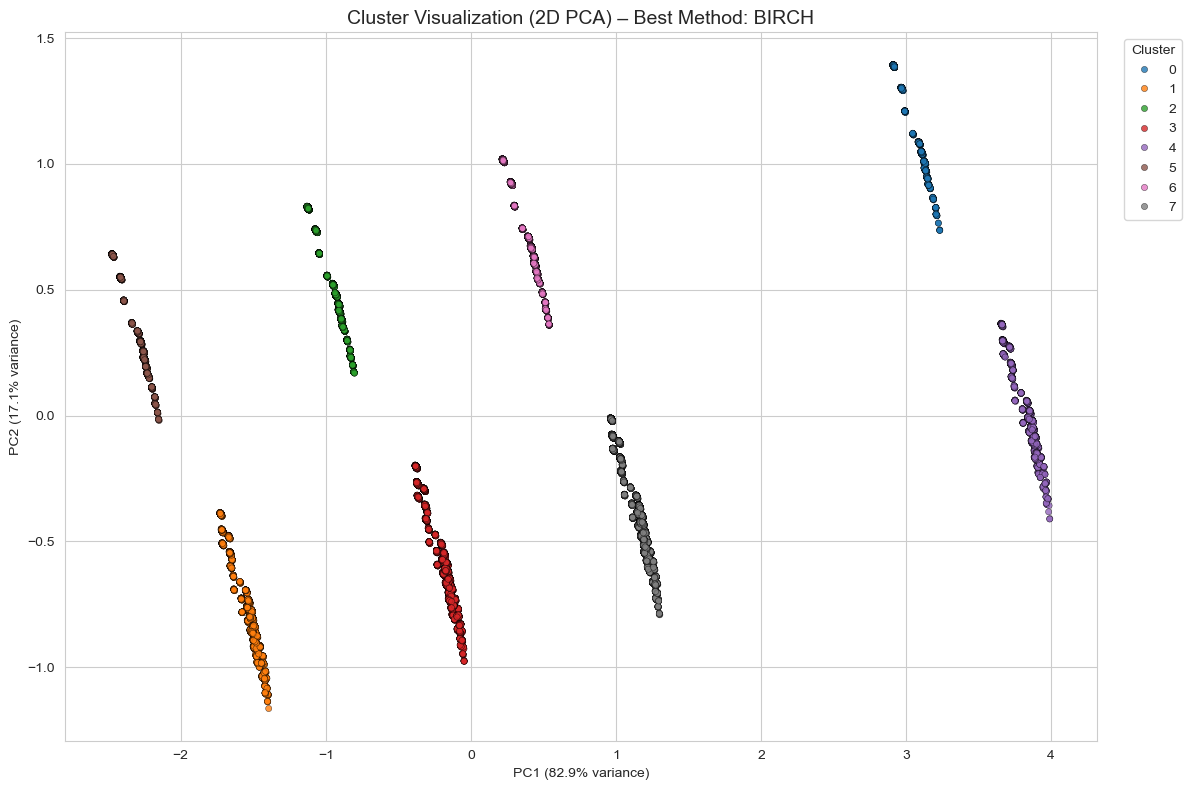

In [8]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')

french_stop_words = stopwords.words('french')

my_extra_words = [
    'incident', 'client', 'signale', 'demande', 'reclamation', 'bonjour', 
    'assistance', 'problème', 'rapporte', 'réalisée', 'réclamation', 'service',
    'certaines', 'continue', 'depuis', 'important', 'lors', 'matin', 
    'non', 'soirée', 'très', 'merci', 'cordialement'
]
french_stop_words.extend(my_extra_words)

try:
    df = pd.read_csv('algerietelecom.csv')
    print("Data Loaded Successfully.")
except FileNotFoundError:
    print("Error: 'algerietelecom.csv' not found.")
    exit()


for col in ['sentiment', 'wilaya']:
    df[col] = df[col].astype(str).str.capitalize()


selected_keywords = [
    'coupure', 'débit', 'facturation', 'faible', 
    'incorrectement', 'installation', 
    'modem', 'contrat', 'téléphonique', 'image'
]


preprocessor = ColumnTransformer(
    transformers=[ 
        ('text', TfidfVectorizer(stop_words=french_stop_words, vocabulary=selected_keywords), 'texte_reclamation'),
        ('nominal_categorie', OneHotEncoder(handle_unknown='ignore'), ['categorie']),
        ('nominal_canal', OneHotEncoder(handle_unknown='ignore'), ['canal']),
        ('nominal_wilaya', OneHotEncoder(handle_unknown='ignore'), ['wilaya']),
        ('ordinal_urgence', OrdinalEncoder(categories=[['Basse', 'Moyenne', 'Élevée', 'Critique']], handle_unknown='use_encoded_value', unknown_value=-1), ['urgence']),
        
        
    ]
)


print("Transforming data...")
X_transformed = preprocessor.fit_transform(df)
print("Applying SVD to densify clusters...")
svd = TruncatedSVD(n_components=2, random_state=42)
X_reduced = svd.fit_transform(X_transformed)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
print("Running multiple clustering algorithms for comparison...")

def safe_metrics(X, labels, name):
    unique_labels = set(labels)
    if len(unique_labels) < 2:
        print(f"[{name}] Warning: Only 1 cluster found — skipping metrics.")
        return {'Silhouette': np.nan, 'CH': np.nan, 'DB': np.nan}
    try:
        sil = silhouette_score(X, labels, sample_size=min(10000, len(X)))  
        ch = calinski_harabasz_score(X, labels)
        db = davies_bouldin_score(X, labels)
        return {'Silhouette': sil, 'CH': ch, 'DB': db}
    except Exception as e:
        print(f"[{name}] Metric error: {e}")
        return {'Silhouette': np.nan, 'CH': np.nan, 'DB': np.nan}


all_labels = {}
results = {}


kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)
all_labels['KMeans'] = labels_kmeans
results['KMeans'] = safe_metrics(X_scaled, labels_kmeans, 'KMeans')


gmm = GaussianMixture(n_components=7, random_state=62, covariance_type='diag') 
labels_gmm = gmm.fit_predict(X_scaled)
all_labels['GMM'] = labels_gmm
results['GMM'] = safe_metrics(X_scaled, labels_gmm, 'GMM')


print("[BIRCH] Running BIRCH clustering with n_clusters=6...")
birch = Birch(n_clusters=8, threshold=0.5)
labels_birch = birch.fit_predict(X_scaled)
all_labels['BIRCH'] = labels_birch
results['BIRCH'] = safe_metrics(X_scaled, labels_birch, 'BIRCH')
print(f"[BIRCH] Completed. All points assigned to 6 clusters.")


from sklearn.cluster import MiniBatchKMeans
mbk = MiniBatchKMeans(n_clusters=8, random_state=32, batch_size=2024)
labels_mbk = mbk.fit_predict(X_scaled)
all_labels['MiniBatchKMeans'] = labels_mbk
results['MiniBatchKMeans'] = safe_metrics(X_scaled, labels_mbk, 'MiniBatchKMeans')

print("\n" + "="*70)
print("CLUSTERING METRICS COMPARISON")
print("="*70)
print(f"{'Algorithm':<15} {'Silhouette ↑':<15} {'Calinski-Harabasz ↑':<20} {'Davies-Bouldin ↓'}")
print("-"*70)
for name, metrics in results.items():
    sil = f"{metrics['Silhouette']:.4f}" if not np.isnan(metrics['Silhouette']) else "N/A"
    ch  = f"{metrics['CH']:.1f}" if not np.isnan(metrics['CH']) else "N/A"
    db  = f"{metrics['DB']:.4f}" if not np.isnan(metrics['DB']) else "N/A"
    print(f"{name:<15} {sil:<15} {ch:<20} {db}")

valid_scores = {
    name: results[name]['Silhouette'] 
    for name in results 
    if not np.isnan(results[name]['Silhouette'])
}
if valid_scores:
    best_algo = max(valid_scores, key=valid_scores.get)
    print(f"\n Best method: {best_algo} (Silhouette = {valid_scores[best_algo]:.4f})")
    df['Cluster'] = all_labels[best_algo]
else:
    print("\n No valid scores — falling back to KMeans.")
    best_algo = 'KMeans'
    df['Cluster'] = all_labels['KMeans']

print("\n" + "="*50)
print("CLUSTER CONTENTS INSPECTION")
print("="*50)

unique_clusters = sorted(df['Cluster'].unique())
feature_names = preprocessor.get_feature_names_out()
text_feat_indices = [i for i, f in enumerate(feature_names) if 'text__' in f]
text_feat_names = [f.replace('text__', '') for f in feature_names if 'text__' in f]
X_text_only = X_transformed[:, text_feat_indices]

for cluster_id in unique_clusters: 
    cluster_data = df[df['Cluster'] == cluster_id]
    size = len(cluster_data)
    
    print(f"\n[CLUSTER {cluster_id}] (Size: {size} rows)")
    wilaya_counts = cluster_data['wilaya'].value_counts()
    top_5_wilayas = wilaya_counts.head(8)
    print(f"   -> Top 5 Wilayas:")
    for rank, (wilaya, count) in enumerate(top_5_wilayas.items(), start=1):
        pct = (count / size) * 100
        print(f"      {rank}. {wilaya} ({count} complaints, {pct:.1f}%)")
   
    categorie_counts = cluster_data['categorie'].value_counts()
    top_3_categories = categorie_counts.head(9)
    print(f"   -> Top 3 Categories:")
    for rank, (cat, count) in enumerate(top_3_categories.items(), start=1):
      pct = (count / size) * 100
      print(f"      {rank}. {cat} ({count} complaints, {pct:.1f}%)")
    
    top_canal = cluster_data['canal'].mode()[0] if not cluster_data['canal'].mode().empty else "N/A"
    canal_count = (cluster_data['canal'] == top_canal).sum()
    canal_pct = (canal_count / size) * 100 if size > 0 else 0
    print(f"   -> Main Canal: {top_canal} ({canal_count} complaints, {canal_pct:.1f}%)")
    
   
    top_urgence = cluster_data['urgence'].mode()[0] if not cluster_data['urgence'].mode().empty else "N/A"
    urgence_count = (cluster_data['urgence'] == top_urgence).sum()
    urgence_pct = (urgence_count / size) * 100 if size > 0 else 0
    print(f"   -> Main Urgence: {top_urgence} ({urgence_count} complaints, {urgence_pct:.1f}%)")
    
    orig_indices = [i for i, label in enumerate(all_labels[best_algo]) if label == cluster_id]
    if orig_indices:
        cluster_scores = X_text_only[orig_indices].sum(axis=0)
        top_word_idx = np.argmax(cluster_scores)
        top_word = text_feat_names[top_word_idx]
        print(f"   -> Top Keyword: '{top_word.upper()}'")
    
   
    print(f"   -> SAMPLE ROWS (What actual customers are saying):")
    sample_size = min(7, size)
    if sample_size > 0:
        sample_rows = cluster_data[['texte_reclamation']].sample(sample_size, random_state=42)
        for _, row in sample_rows.iterrows():
            print(f"      * {row['texte_reclamation']}")

print("\n" + "="*50)
print("GENERATING CLUSTER VISUALIZATIONS")
print("="*50)


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

vis_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': df['Cluster']
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=vis_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='tab10',
    s=20,
    alpha=0.8,
    edgecolor='k',
    linewidth=0.3
)
plt.title(f'Cluster Visualization (2D PCA) – Best Method: {best_algo}', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()



## . Detailed Cluster Interpretation & Strategic Insights

Our BIRCH algorithm identified **8 distinct customer segments**. Below is the detailed interpretation of the hidden patterns found in each group and their impact on decision-making.

### **Cluster 0: "The Red Zone" (Critical Line Cuts)**
* **The Data:** Phone Channel + Critical Urgency + Keyword *"Téléphonique"*.
* **Hidden Pattern:** These are not just technical complaints; they are **Churn Risks**. These customers are calling (highest effort channel) because they have a total service blackout. They are panicked and likely to cancel their subscription if not answered immediately.
* **Strategic Action:** **Priority Routing.** Remove these callers from the general queue and route them directly to Tier-2 Network Technicians.

### **Cluster 1: "The Streamers" (Quality of Experience)**
* **The Data:** Web Channel + High Urgency + Keyword *"Image"*.
* **Hidden Pattern:** These are likely **"Triple Play" customers** (Internet + TV + Phone). They have service, but the bandwidth is unstable, causing pixelated TV ("Image"). They are tech-savvy enough to use the Web portal but frustrated by quality, not connectivity.
* **Strategic Action:** **Automated Diagnostics.** Trigger an automatic bandwidth stability test on their line the moment the ticket is created.

### **Cluster 2: "The Efficiency Drain" (Billing Enquiries)**
* **The Data:** Phone Channel + Low Urgency + Keyword *"Incorrectement"*.
* **Hidden Pattern:** **Operational Waste.** This is a massive group (~16,000 complaints) of people calling human agents for simple math problems (billing errors). They are clogging the phone lines for low-priority issues.
* **Strategic Action:** **Call Deflection.** Implement an IVR (Interactive Voice Response) that reads their latest bill status and balance *before* connecting them to an agent.

### **Cluster 3: "The Waiting Room" (New Installations)**
* **The Data:** Web Channel + Low Urgency + Keyword *"Installation"*.
* **Hidden Pattern:** **Anxiety of New Customers.** These users are simply asking: *"When will I get internet?"* They are using the web, which suggests they are digital-first users.
* **Strategic Action:** **Self-Service Tracker.** Add a "Track My Order" progress bar on the website homepage to prevent these tickets from being created in the first place.

### **Cluster 4: "The Admin Panic" (Contract Disputes)**
* **The Data:** Web Channel + Critical Urgency + Keyword *"Contrat"*.
* **Hidden Pattern:** **Misclassified Urgency.** These users are marking administrative paperwork issues as "Critical" (Life or Death) to get attention. This pollutes the "Critical" queue for real emergencies (like Cluster 0).
* **Strategic Action:** **Auto-Downgrade.** Automatically reclassify these tickets to "Medium Priority" and route them to the Administrative/Legal team, not Technical Support.

### **Cluster 5: "The Noisy Line" (Voice Quality)**
* **The Data:** Phone Channel + High Urgency + Keyword *"Téléphonique"*.
* **Hidden Pattern:** Distinct from Cluster 0 (Total Cut), these users have a working line but hear static/noise. This is usually a physical infrastructure issue (wet cables, old copper).
* **Strategic Action:** **Field Maintenance.** These require physical intervention. Group these complaints by geographic zone (Wilaya) to deploy maintenance trucks efficiently.

### **Cluster 6: "The TV Generation" (Decoder Support)**
* **The Data:** Phone Channel + Medium Urgency + Keyword *"Image"*.
* **Hidden Pattern:** Unlike Cluster 1 (Web users), these are likely **older or less tech-savvy users** (preferring Phone) struggling with their TV Decoder. They need step-by-step hand-holding.
* **Strategic Action:** **Scripting.** Provide Call Center agents with a specific "Decoder Reset Script" for phone interactions.

### **Cluster 7: "The Hardware DIYers" (Modem Config)**
* **The Data:** Web Channel + Medium Urgency + Keyword *"Modem"*.
* **Hidden Pattern:** **Self-Help Failure.** These are the largest group of web users (~24,000). They are trying to configure their own routers but failing.
* **Strategic Action:** **Education Push.** Immediately email a "One-Click Configuration Guide" (PDF/Video) to anyone submitting a ticket with the word "Modem."

## 6. Classification Model (Random Forest)
**Feature Engineering: The "Smart Label" Strategy**
Before training our Random Forest Classifier, we refined the `suggested_action` attribute to solve specific data quality issues:
* **The Problem:** The original dataset contained "noisy" labels where the suggested actions were often random or not specific to the actual complaint text.
* **The Solution:** We applied **Domain Knowledge** and statistical rules to map specific problems to precise solutions (e.g., "Cable Cut" + "Critical" → "Tech Intervention").
* **The Result:** A new, high-quality training dataset (`algerietelecom_realistic_train.csv`) that allows the AI to learn actual problem-solving logic.
* **Input:** Text + Metadata (Category, Urgency, etc.)
* **Pipeline:** TF-IDF for text, OneHotEncoder for categories.
* **Goal:** Achieve ~82% accuracy.

In [6]:
import pandas as pd
import numpy as np
import joblib  # For saving the model
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

try:
    df = pd.read_csv('algerietelecom_realistic_train.csv')
    print(f"Dataset loaded: {df.shape[0]} rows.")
except FileNotFoundError:
    print("Error: 'algerietelecom_realistic_train.csv' not found. Please run the feature engineering script first.")
    exit()


df = df.dropna(subset=['texte_reclamation', 'suggested_action'])
df['combined_text'] = df['categorie'].astype(str) + " " + df['texte_reclamation'].astype(str)
X = df[['combined_text', 'canal', 'urgence', 'sentiment', 'wilaya']]
y = df['suggested_action']

categorical_cols = ['canal', 'urgence', 'sentiment', 'wilaya']

preprocessor = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=3000, stop_words=None), 'combined_text'),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=20, random_state=42, class_weight='balanced'))
])

print("Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Random Forest Model (this may take a moment)...")
model.fit(X_train, y_train)

print("\nPredicting on Test Set...")
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2%}")

print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred))

joblib.dump(model, 'at_complaint_classifier.pkl')
print("Model saved as 'at_complaint_classifier.pkl'. Ready for Website!")

print("\n--- TEST PREDICTION ---")
new_complaint = pd.DataFrame([{
    'combined_text': "coupure totale internet et je suis très en colère",
    'canal': "Centre d'appel",
    'urgence': "Critique",
    'sentiment': "Négatif",
    'wilaya': "Alger"
}])

prediction = model.predict(new_complaint)[0]
print(f"Input: 'Angry customer, Critical outage in Algiers'")
print(f"Model Suggests: {prediction}")

Dataset loaded: 100000 rows.
Splitting data...
Training Random Forest Model (this may take a moment)...

Predicting on Test Set...

Model Accuracy: 81.52%

DETAILED CLASSIFICATION REPORT
                                      precision    recall  f1-score   support

        Accélération Mise en Service       0.88      0.80      0.84       352
Audit Facturation & Geste Commercial       0.83      0.78      0.80       431
               Confirmation Date RDV       0.95      0.96      0.95      1580
                 Envoi Guide PDF/SMS       0.60      0.74      0.66      1488
            Escalade Manager & Suivi       0.84      0.84      0.84       605
         Explication Détails Facture       0.94      0.94      0.94      1880
  Intervention Technique Prioritaire       0.91      0.92      0.92       791
        Optimisation Wifi à Distance       0.68      0.79      0.73      2446
           Proposition Upgrade Offre       0.91      0.84      0.87       451
            Reconfiguration Déco

## 7. Deployment (Web API)
We use **Flask** to serve the model. 
* **Endpoint:** `/api/predict`
* **Frontend:** `complaint_predictor.html`
* **Features:** Auto-translation (Arabic/Darija -> French) and Confidence scoring.

In [10]:
# Run Flask App
from flask import Flask, request, jsonify, send_from_directory
from flask_cors import CORS
import pandas as pd
import joblib
import re
from typing import Dict, Tuple

app = Flask(__name__)
CORS(app)

# Load Model
MODEL_PATH = 'at_complaint_classifier.pkl'
try:
    model = joblib.load(MODEL_PATH)
    print(" Model loaded successfully!")
except:
    print(" Model not found. Did you run Cell 3?")


def detect_language(text):
    if re.search(r'[\u0600-\u06FF]', text): return 'arabic'
    if any(w in text.lower() for w in ['internet', 'wifi', 'problem']): return 'english'
    return 'french'

def translate_to_french(text, lang):
   
    if lang == 'french': return text.lower()
    replacements = {
        'انترنت': 'internet', 'بطيء': 'lent', 'كابل': 'cable', 'مقطوع': 'arraché',
        'slow': 'lent', 'cut': 'coupé', 'bill': 'facture', 'bad': 'mauvais'
    }
    trans = text.lower()
    for k, v in replacements.items():
        trans = trans.replace(k, v)
    return trans

@app.route('/')
def index():
    return send_from_directory('.', 'complaint_predictor.html')

@app.route('/api/predict', methods=['POST'])
def predict():
    data = request.json
    try:
        orig_text = data['texte_reclamation']
        lang = detect_language(orig_text)
        trans_text = translate_to_french(orig_text, lang)
        combined = f"{data['categorie']} {trans_text}"
        input_data = pd.DataFrame([{
            'combined_text': combined,
            'canal': data['canal'],
            'urgence': data['urgence'],
            'sentiment': data['sentiment'],
            'wilaya': data['wilaya']
        }])
        
        pred = model.predict(input_data)[0]
        probs = model.predict_proba(input_data)[0]
        
        classes = model.classes_
        top_idx = probs.argsort()[-3:][::-1]
        top_preds = [{'action': classes[i], 'confidence': float(probs[i])} for i in top_idx]

        return jsonify({
            'success': True,
            'prediction': pred,
            'language_detected': lang,
            'top_predictions': top_preds
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 500


if __name__ == '__main__':
    print(" Server is running! Open this URL in your browser:")
    print(" http://localhost:5000")
    app.run(port=5000)

 Model loaded successfully!
 Server is running! Open this URL in your browser:
 http://localhost:5000
 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [05/Feb/2026 00:19:00] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [05/Feb/2026 00:19:00] "GET /algtelecome.png HTTP/1.1" 404 -
127.0.0.1 - - [05/Feb/2026 00:19:00] "GET /ic.png HTTP/1.1" 404 -
127.0.0.1 - - [05/Feb/2026 00:19:00] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [05/Feb/2026 00:19:22] "POST /api/predict HTTP/1.1" 200 -
